In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("student-mat.csv", sep=';')
print(data.head())
print(data.columns)

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       '

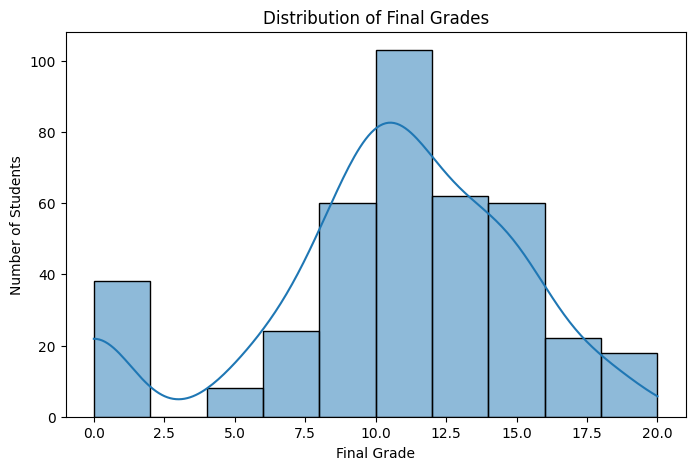

In [2]:
plt.figure(figsize=(8,5))
sns.histplot(data['G3'], bins=10, kde=True)
plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")
plt.savefig("figure1.png")
plt.show()

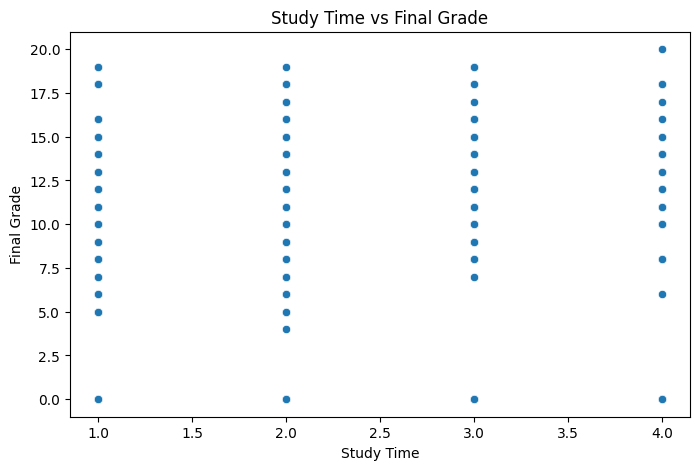

In [3]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='studytime', y='G3', data=data)
plt.title("Study Time vs Final Grade")
plt.xlabel("Study Time")
plt.ylabel("Final Grade")
plt.savefig("figure2.png")
plt.show()

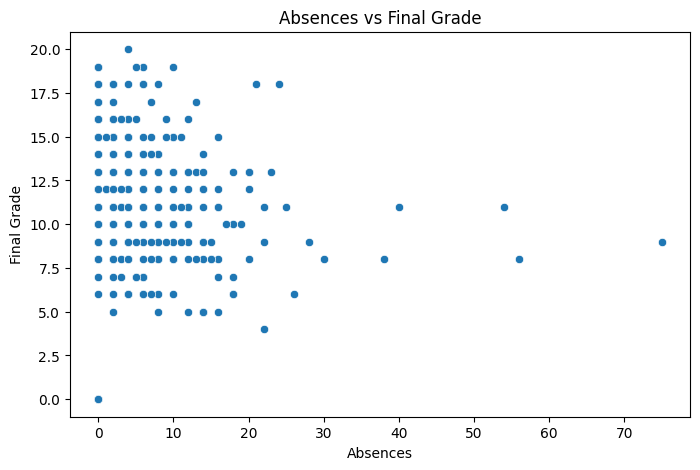

In [4]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='absences', y='G3', data=data)
plt.title("Absences vs Final Grade")
plt.xlabel("Absences")
plt.ylabel("Final Grade")
plt.savefig("figure3.png")
plt.show()

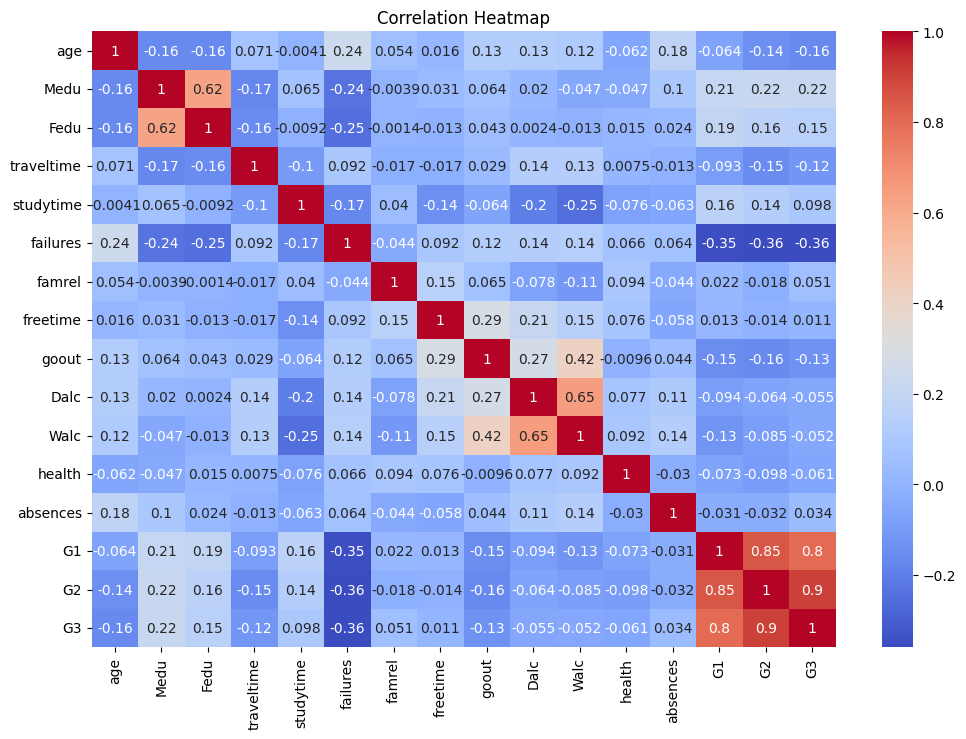

In [5]:
plt.figure(figsize=(12,8))
numeric_data = data.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.savefig("figure4.png")
plt.show()




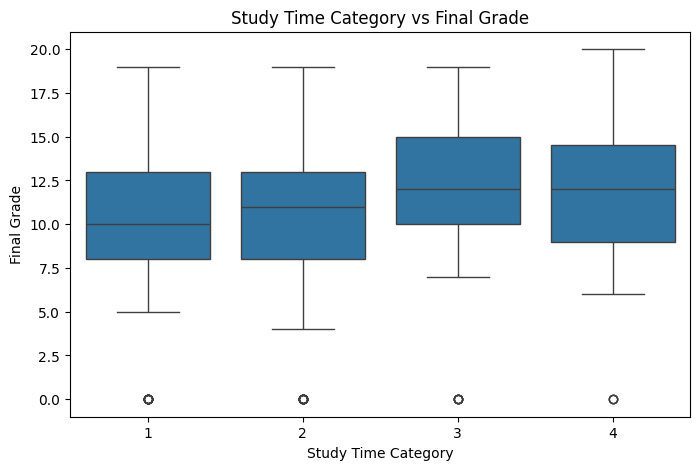

In [6]:
plt.figure(figsize=(8,5))
sns.boxplot(x='studytime', y='G3', data=data)
plt.title("Study Time Category vs Final Grade")
plt.xlabel("Study Time Category")
plt.ylabel("Final Grade")
plt.savefig("figure5.png")
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

X = data[['studytime', 'absences', 'G1', 'G2']]
y = data['G3']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression Results")
print("R2 Score:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))

Linear Regression Results
R2 Score: 0.8065024928556156
MAE: 1.2974847789242745
MSE: 4.253474472421519


In [8]:
from sklearn.ensemble import RandomForestRegressor

X = data[['studytime', 'absences', 'G1', 'G2']]
y = data['G3']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Results")
print("R2 Score:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))

Random Forest Results
R2 Score: 0.8682039614314697
MAE: 1.0531688675470186
MSE: 2.8971488774748004


In [9]:
from sklearn.tree import DecisionTreeRegressor

X = data[['studytime', 'absences', 'G1', 'G2']]
y = data['G3']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Results")
print("R2 Score:", r2_score(y_test, y_pred_dt))
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("MSE:", mean_squared_error(y_test, y_pred_dt))


Decision Tree Results
R2 Score: 0.8250101192464856
MAE: 1.1638655462184875
MSE: 3.846638655462185
